In [178]:
import numpy as np
import matplotlib.pyplot as plt

In [179]:
rng = np.random.default_rng(42)

#generate 10000 gaussian points for each class.
c1 = rng.multivariate_normal([-5, -2], np.eye(2), size=10000)
c2 = rng.multivariate_normal([0, 5], np.eye(2), size=10000)
c3 = rng.multivariate_normal([5, 0], np.eye(2), size=10000)

print(c1.shape, c2.shape, c3.shape)

(10000, 2) (10000, 2) (10000, 2)


In [180]:
#train-test-split
rng.shuffle(c1)
rng.shuffle(c2)
rng.shuffle(c3)

train1, test1 = c1[:8000], c1[8000:]
train2, test2 = c2[:8000], c2[8000:]
train3, test3 = c3[:8000], c3[8000:]

print(train1.shape, test1.shape, train2.shape, test2.shape, train3.shape, test3.shape)

(8000, 2) (2000, 2) (8000, 2) (2000, 2) (8000, 2) (2000, 2)


In [181]:
means = np.array([data.mean(axis=0) for data in (train1, train2, train3)])
variances = np.array([data.var(axis=0, ddof=0) for data in (train1, train2, train3)])

for k in range(3):
    print(f'Class {k+1}: Mean = {means[k]}, Variance = {variances[k]}')

Class 1: Mean = [-5.00150914 -1.98668472], Variance = [0.98476914 1.03045934]
Class 2: Mean = [1.29472461e-03 5.00520748e+00], Variance = [0.99923111 1.03645018]
Class 3: Mean = [ 4.98943625 -0.00755115], Variance = [1.00722521 1.00784519]


In [182]:
shared_variance = variances.mean()
shared_covariance = shared_variance * np.eye(2)

print("Shared variance: ", shared_variance)
print("Shared Covariance:\n", shared_covariance)

Shared variance:  1.010996695572537
Shared Covariance:
 [[1.0109967 0.       ]
 [0.        1.0109967]]


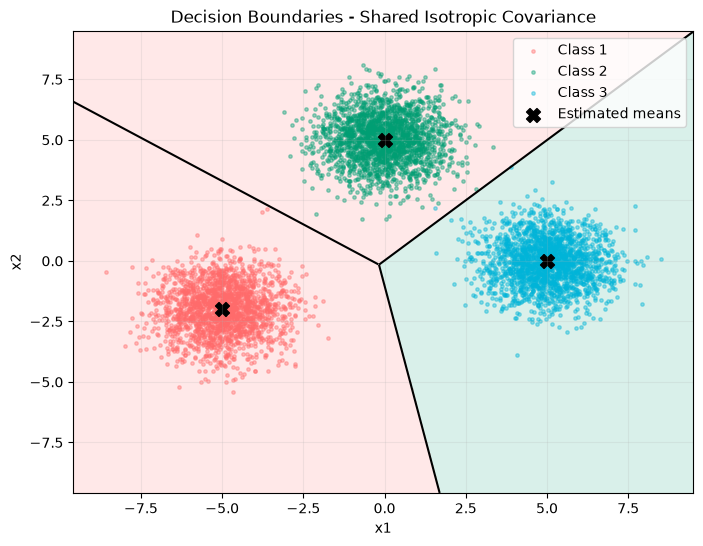

In [183]:
import matplotlib.pyplot as plt

test_data = np.vstack((test1, test2, test3))

lower = test_data.min() - 1
upper = test_data.max() + 1

x1, x2 = np.meshgrid(
    np.linspace(lower, upper, 400),
    np.linspace(lower, upper, 400)
)
points = np.column_stack((x1.ravel(), x2.ravel()))

#shared isotropic covariance
scores = (
    points @ means.T - 0.5 * np.sum(means**2, axis=1)
) / shared_variance

regions = np.argmax(scores, axis=1).reshape(x1.shape)

plt.figure(figsize=(8,6))
colors = ["#FF6B6B",  "#009E73", "#00B4D8"]

plt.contourf(
    x1, x2, regions,
    levels = [-0.5, 1.5, 2.5],
    colors = colors, alpha=0.15
)

for i, j in [(0,1), (0,2), (1,2)]:
    third = 3 - i - j
    difference = (scores[:, i] - scores[:, j]).reshape(x1.shape)
    active = (
        np.maximum(scores[:, i], scores[:, j]) >= scores[:, third]
    ).reshape(x1.shape)

    boundary = np.ma.masked_where(~active, difference)
    values = boundary.compressed()

    if values.size and values.min() < 0 < values.max():
        plt.contour(
            x1, x2, boundary, levels = [0],
            colors="black", linewidth=1.5
        )

for k, data in enumerate((test1, test2, test3)):
    plt.scatter(
        data[:, 0], data[:, 1],
        s=6, alpha=0.4, color = colors[k], label=f"Class {k+1}"
    )

plt.scatter(
    means[:, 0], means[:, 1],
    marker = 'X', s=100, color="black", label="Estimated means"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Decision Boundaries - Shared Isotropic Covariance")
plt.legend()
plt.grid(alpha=0.2)
plt.xlim(lower, upper)
plt.ylim(lower, upper)
plt.gca().set_aspect("auto")
plt.show()

In [184]:
test_data = np.vstack((test1, test2, test3))
actual = np.concatenate([np.full(len(data), k) for k, data in enumerate((test1, test2, test3))])

test_scores = (test_data @ means.T - 0.5 * np.sum(means**2, axis=1)) / shared_variance
predicted = np.argmax(test_scores, axis=1)

confusion_matrix = np.zeros((3,3), dtype=int)
np.add.at(confusion_matrix, (actual, predicted), 1)

print("Confusion matrix (rows: actual, columns: predicted):")
print(confusion_matrix)
print(f"Test accuracy: {np.trace(confusion_matrix) / confusion_matrix.sum() * 100:.2f}%")

Confusion matrix (rows: actual, columns: predicted):
[[2000    0    0]
 [   0 2000    0]
 [   0    1 1999]]
Test accuracy: 99.98%


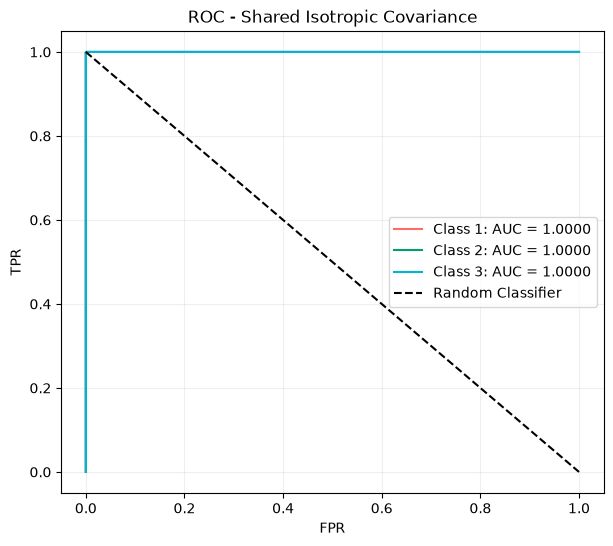

In [185]:
#convert test scores into probabilites
shift = test_scores - test_scores.max(axis=1, keepdims=True)
prob = np.exp(shift)
prob /= prob.sum(axis=1, keepdims=True)

plt.figure(figsize=(7,6))

for k in range(3):
    positive = (actual == k)
    scores_k = prob[:, k]

    #arrange by decreasing prob
    order = np.argsort(-scores_k)
    sorted_scores = scores_k[order]
    sorted_positive = positive[order]

    #grp equal scores in same threshold
    ends = np.r_[np.where(np.diff(sorted_scores) != 0)[0], len(sorted_scores) - 1]

    tp = np.cumsum(sorted_positive)[ends]
    fp = np.cumsum(~sorted_positive)[ends]

    tpr = np.r_[0, tp / positive.sum()]
    fpr = np.r_[0, fp / (~positive).sum()]

    auc = np.sum(np.diff(fpr) * (tpr[:-1] + tpr[1:]) / 2)
    plt.plot(fpr, tpr, color=colors[k],
             label=f'Class {k+1}: AUC = {auc:.4f}')

plt.plot([0,1], [1,0], "k--", label="Random Classifier")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC - Shared Isotropic Covariance")
plt.legend()
plt.grid(alpha=0.2)
plt.show()
    


In [186]:
#isotropic with different covariance
# Generate covariances: I, 2I, and 3I.
class1 = rng.multivariate_normal([-5, -2], np.eye(2), size=10000)
class2 = rng.multivariate_normal([0, 5], 2 * np.eye(2), size=10000)
class3 = rng.multivariate_normal([5, 0], 3 * np.eye(2), size=10000)

for data in (class1, class2, class3): rng.shuffle(data)
(train1, test1), (train2, test2), (train3, test3) = [
    (data[:8000], data[8000:]) for data in (class1, class2, class3)
]

means = np.array([data.mean(axis=0) for data in (train1, train2, train3)])
variances = np.array([data.var(axis=0, ddof=0) for data in (train1, train2, train3)])

class_variances = variances.mean(axis=1)
isotropic_covariances = np.array([v * np.eye(2) for v in class_variances])

for k in range(3):
    print(f"Class {k+1}: Mean = {means[k]}")
    print("Estimated isotropic covariance:\n", isotropic_covariances[k])

Class 1: Mean = [-5.00838464 -2.01259521]
Estimated isotropic covariance:
 [[0.99484734 0.        ]
 [0.         0.99484734]]
Class 2: Mean = [1.30779013e-03 4.98288824e+00]
Estimated isotropic covariance:
 [[2.02481487 0.        ]
 [0.         2.02481487]]
Class 3: Mean = [ 5.02062422e+00 -3.99289648e-03]
Estimated isotropic covariance:
 [[3.03896642 0.        ]
 [0.         3.03896642]]


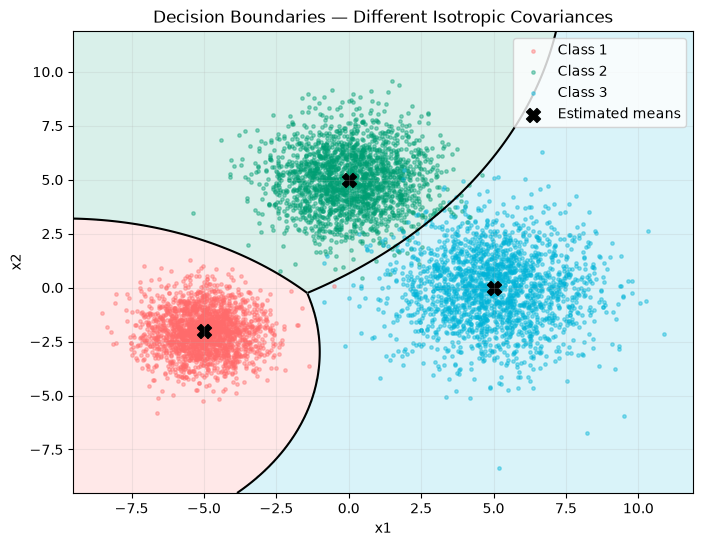

In [187]:
#boundary
test_data = np.vstack((test1, test2, test3))

lower = test_data.min() - 1
upper = test_data.max() + 1

x1, x2 = np.meshgrid(
    np.linspace(lower, upper, 400),
    np.linspace(lower, upper, 400)
)
points = np.column_stack((x1.ravel(), x2.ravel()))

scores = np.zeros((len(points), 3))

for k in range(3):
    difference = points - means[k]
    squared_distance = np.sum(difference**2, axis=1)

    scores[:, k] = (
        -squared_distance / (2 * class_variances[k])
        - np.log(class_variances[k])
    )

regions = np.argmax(scores, axis=1).reshape(x1.shape)

plt.figure(figsize=(8, 6))
plt.contourf(
    x1, x2, regions,
    levels=[-0.5, 0.5, 1.5, 2.5],
    colors=colors, alpha=0.15
)

for i, j in [(0, 1), (0, 2), (1, 2)]:
    third = 3 - i - j
    difference = (scores[:, i] - scores[:, j]).reshape(x1.shape)
    active = (
        np.maximum(scores[:, i], scores[:, j]) >= scores[:, third]
    ).reshape(x1.shape)

    boundary = np.ma.masked_where(~active, difference)
    values = boundary.compressed()

    if values.size and values.min() < 0 < values.max():
        plt.contour(
            x1, x2, boundary, levels=[0],
            colors="black", linewidths=1.5
        )

for k, data in enumerate((test1, test2, test3)):
    plt.scatter(
        data[:, 0], data[:, 1],
        s=6, alpha=0.4, color=colors[k], label=f"Class {k+1}"
    )

plt.scatter(
    means[:, 0], means[:, 1],
    marker="X", s=100, color="black", label="Estimated means"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Decision Boundaries — Different Isotropic Covariances")
plt.legend()
plt.grid(alpha=0.2)
plt.xlim(lower, upper)
plt.ylim(lower, upper)
plt.gca().set_aspect("auto")
plt.show()

In [188]:
#confusion matrix
actual = np.concatenate([
    np.full(len(data), k)
    for k, data in enumerate((test1, test2, test3))
])

test_scores = np.zeros((len(test_data), 3))

for k in range(3):
    difference = test_data - means[k]
    squared_distance = np.sum(difference**2, axis=1)

    test_scores[:, k] = (
        -squared_distance / (2 * class_variances[k])
        - np.log(class_variances[k])
    )

predicted = np.argmax(test_scores, axis=1)

confusion_matrix = np.zeros((3, 3), dtype=int)
np.add.at(confusion_matrix, (actual, predicted), 1)

print("Confusion matrix (rows: actual, columns: predicted):")
print(confusion_matrix)
print(f"Test accuracy: {np.trace(confusion_matrix) / confusion_matrix.sum() * 100:.2f}%")

Confusion matrix (rows: actual, columns: predicted):
[[1999    0    1]
 [   0 1975   25]
 [   0   30 1970]]
Test accuracy: 99.07%


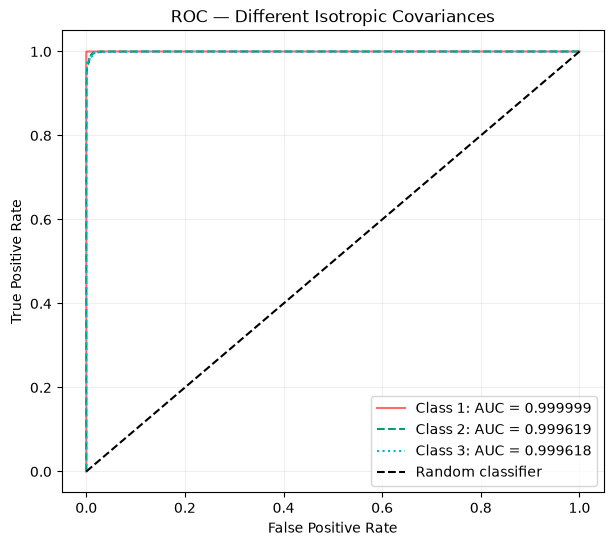

In [189]:
#roc curve
shifted = test_scores - test_scores.max(axis=1, keepdims=True)
probabilities = np.exp(shifted)
probabilities /= probabilities.sum(axis=1, keepdims=True)

styles = ["-", "--", ":"]
plt.figure(figsize=(7, 6))

for k in range(3):
    positive = (actual == k)
    scores_k = probabilities[:, k]

    order = np.argsort(-scores_k)
    sorted_scores = scores_k[order]
    sorted_positive = positive[order]

    ends = np.r_[np.where(np.diff(sorted_scores) != 0)[0],
                 len(sorted_scores) - 1]

    tp = np.cumsum(sorted_positive)[ends]
    fp = np.cumsum(~sorted_positive)[ends]

    tpr = np.r_[0, tp / positive.sum()]
    fpr = np.r_[0, fp / (~positive).sum()]

    auc = np.sum(np.diff(fpr) * (tpr[:-1] + tpr[1:]) / 2)

    plt.plot(
        fpr, tpr, color=colors[k], linestyle=styles[k],
        label=f"Class {k+1}: AUC = {auc:.6f}"
    )

plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Different Isotropic Covariances")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [190]:
#diagonal with shared covariance
diagonal_covariance = np.diag([1.0, 2.0])

class1 = rng.multivariate_normal([-5, -2], diagonal_covariance, size=10000)
class2 = rng.multivariate_normal([0, 5], diagonal_covariance, size=10000)
class3 = rng.multivariate_normal([5, 0], diagonal_covariance, size=10000)

for data in (class1, class2, class3): rng.shuffle(data)
(train1, test1), (train2, test2), (train3, test3) = [(data[:8000], data[8000:]) for data in (class1, class2, class3)]

means = np.array([data.mean(axis=0) for data in (train1, train2, train3)])
variances = np.array([data.var(axis=0, ddof=0) for data in (train1, train2, train3)])

shared_diagonal_covariance = np.diag(variances.mean(axis=0))

print("Estimated means:\n", means)
print("Estimated shared diagonal covariance:\n", shared_diagonal_covariance)

Estimated means:
 [[-4.98700108 -1.97349223]
 [-0.02443049  5.03265851]
 [ 4.99637034  0.02010238]]
Estimated shared diagonal covariance:
 [[0.98538297 0.        ]
 [0.         2.01234942]]


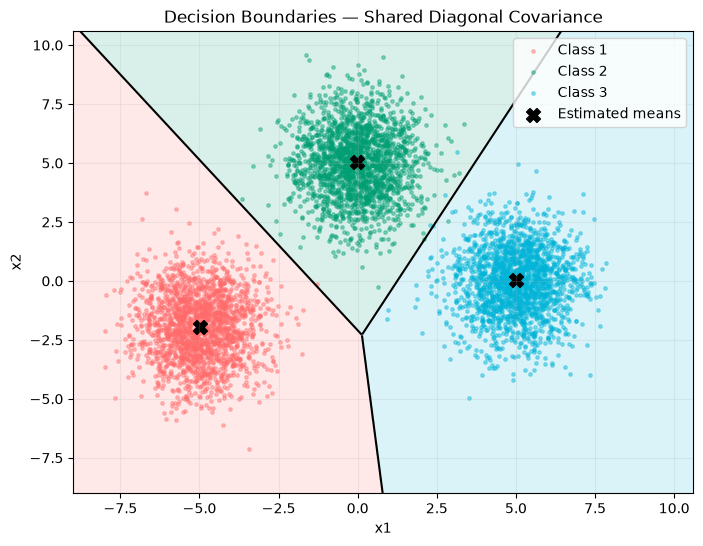

In [191]:
test_data = np.vstack((test1, test2, test3))

lower = test_data.min() - 1
upper = test_data.max() + 1

x1, x2 = np.meshgrid(
    np.linspace(lower, upper, 400),
    np.linspace(lower, upper, 400)
)
points = np.column_stack((x1.ravel(), x2.ravel()))

A = np.linalg.inv(shared_diagonal_covariance)

# Common terms cancel because covariance and priors are shared.
scores = points @ A @ means.T - 0.5 * np.sum((means @ A) * means, axis=1)
regions = np.argmax(scores, axis=1).reshape(x1.shape)

plt.figure(figsize=(8, 6))

plt.contourf(
    x1, x2, regions,
    levels=[-0.5, 0.5, 1.5, 2.5],
    colors=colors, alpha=0.15
)

for i, j in [(0, 1), (0, 2), (1, 2)]:
    third = 3 - i - j
    difference = (scores[:, i] - scores[:, j]).reshape(x1.shape)
    active = (
        np.maximum(scores[:, i], scores[:, j]) >= scores[:, third]
    ).reshape(x1.shape)

    boundary = np.ma.masked_where(~active, difference)
    values = boundary.compressed()

    if values.size and values.min() < 0 < values.max():
        plt.contour(
            x1, x2, boundary, levels=[0],
            colors="black", linewidths=1.5
        )

for k, data in enumerate((test1, test2, test3)):
    plt.scatter(
        data[:, 0], data[:, 1],
        s=6, alpha=0.4, color=colors[k], label=f"Class {k+1}"
    )

plt.scatter(
    means[:, 0], means[:, 1],
    marker="X", s=100, color="black", label="Estimated means"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Decision Boundaries — Shared Diagonal Covariance")
plt.legend()
plt.grid(alpha=0.2)
plt.xlim(lower, upper)
plt.ylim(lower, upper)
plt.gca().set_aspect("auto")
plt.show()

In [192]:
actual = np.concatenate([
    np.full(len(data), k)
    for k, data in enumerate((test1, test2, test3))
])

test_scores = test_data @ A @ means.T - 0.5 * np.sum((means @ A) * means, axis=1)
predicted = np.argmax(test_scores, axis=1)

confusion_matrix = np.zeros((3, 3), dtype=int)
np.add.at(confusion_matrix, (actual, predicted), 1)

print("Confusion matrix (rows: actual, columns: predicted):")
print(confusion_matrix)
print(f"Test accuracy: {np.trace(confusion_matrix) / confusion_matrix.sum() * 100:.2f}%")

Confusion matrix (rows: actual, columns: predicted):
[[1999    1    0]
 [   0 1999    1]
 [   0    4 1996]]
Test accuracy: 99.90%


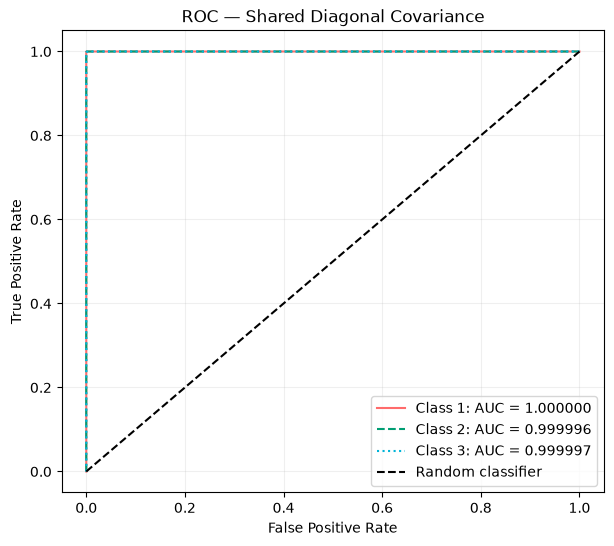

In [193]:
shifted = test_scores - test_scores.max(axis=1, keepdims=True)
probabilities = np.exp(shifted)
probabilities /= probabilities.sum(axis=1, keepdims=True)

styles = ["-", "--", ":"]
plt.figure(figsize=(7, 6))

for k in range(3):
    positive = (actual == k)
    scores_k = probabilities[:, k]

    order = np.argsort(-scores_k)
    sorted_scores = scores_k[order]
    sorted_positive = positive[order]

    ends = np.r_[np.where(np.diff(sorted_scores) != 0)[0],
                 len(sorted_scores) - 1]

    tp = np.cumsum(sorted_positive)[ends]
    fp = np.cumsum(~sorted_positive)[ends]

    tpr = np.r_[0, tp / positive.sum()]
    fpr = np.r_[0, fp / (~positive).sum()]

    auc = np.sum(np.diff(fpr) * (tpr[:-1] + tpr[1:]) / 2)

    plt.plot(
        fpr, tpr, color=colors[k], linestyle=styles[k],
        label=f"Class {k+1}: AUC = {auc:.6f}"
    )

plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Shared Diagonal Covariance")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [194]:
#diagonal with different covariance
diagonal_covariances = np.array([
    np.diag([1.0, 2.0]),
    np.diag([2.0, 3.0]),
    np.diag([4.0, 5.0])
])

class1 = rng.multivariate_normal([-5, -2], diagonal_covariances[0], size=10000)
class2 = rng.multivariate_normal([0, 5], diagonal_covariances[1], size=10000)
class3 = rng.multivariate_normal([5, 0], diagonal_covariances[2], size=10000)

for data in (class1, class2, class3): rng.shuffle(data)
(train1, test1), (train2, test2), (train3, test3) = [
    (data[:8000], data[8000:]) for data in (class1, class2, class3)
]

means = np.array([data.mean(axis=0) for data in (train1, train2, train3)])
variances = np.array([data.var(axis=0, ddof=0) for data in (train1, train2, train3)])
estimated_diagonal_covariances = np.array([np.diag(v) for v in variances])

for k in range(3):
    print(f"Class {k+1}: Mean = {means[k]}")
    print("Estimated diagonal covariance:\n", estimated_diagonal_covariances[k])

Class 1: Mean = [-5.0107095  -2.00588735]
Estimated diagonal covariance:
 [[1.03150489 0.        ]
 [0.         1.98155161]]
Class 2: Mean = [0.01926272 5.0091278 ]
Estimated diagonal covariance:
 [[2.02900587 0.        ]
 [0.         3.06735564]]
Class 3: Mean = [ 4.97364126 -0.01466156]
Estimated diagonal covariance:
 [[4.02778758 0.        ]
 [0.         4.99191883]]


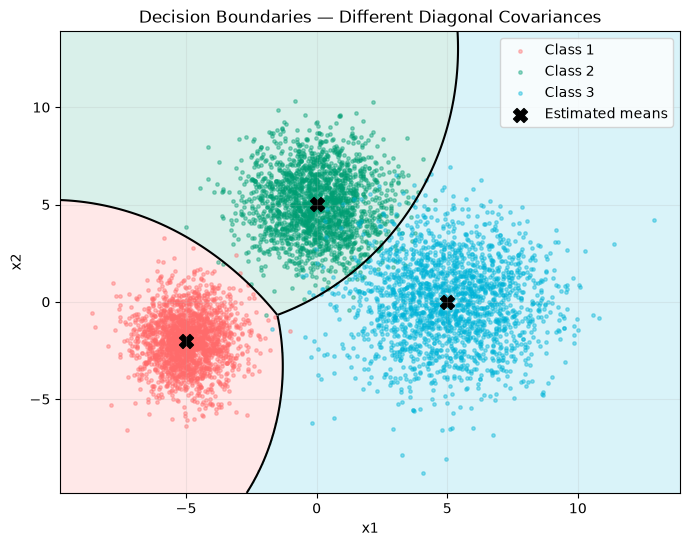

In [195]:
test_data = np.vstack((test1, test2, test3))

lower = test_data.min() - 1
upper = test_data.max() + 1

x1, x2 = np.meshgrid(
    np.linspace(lower, upper, 400),
    np.linspace(lower, upper, 400)
)
points = np.column_stack((x1.ravel(), x2.ravel()))

scores = np.zeros((len(points), 3))

for k in range(3):
    difference = points - means[k]
    scores[:, k] = (
        -0.5 * np.sum(difference**2 / variances[k], axis=1)
        -0.5 * np.sum(np.log(variances[k]))
    )

regions = np.argmax(scores, axis=1).reshape(x1.shape)

plt.figure(figsize=(8, 6))
plt.contourf(
    x1, x2, regions,
    levels=[-0.5, 0.5, 1.5, 2.5],
    colors=colors, alpha=0.15
)

for i, j in [(0, 1), (0, 2), (1, 2)]:
    third = 3 - i - j
    difference = (scores[:, i] - scores[:, j]).reshape(x1.shape)
    active = (
        np.maximum(scores[:, i], scores[:, j]) >= scores[:, third]
    ).reshape(x1.shape)

    boundary = np.ma.masked_where(~active, difference)
    values = boundary.compressed()

    if values.size and values.min() < 0 < values.max():
        plt.contour(
            x1, x2, boundary, levels=[0],
            colors="black", linewidths=1.5
        )

for k, data in enumerate((test1, test2, test3)):
    plt.scatter(
        data[:, 0], data[:, 1],
        s=6, alpha=0.4, color=colors[k], label=f"Class {k+1}"
    )

plt.scatter(
    means[:, 0], means[:, 1],
    marker="X", s=100, color="black", label="Estimated means"
)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Decision Boundaries — Different Diagonal Covariances")
plt.legend()
plt.grid(alpha=0.2)
plt.xlim(lower, upper)
plt.ylim(lower, upper)
plt.gca().set_aspect("auto")
plt.show()

In [196]:
#confusion matrix
actual = np.concatenate([
    np.full(len(data), k)
    for k, data in enumerate((test1, test2, test3))
])

test_scores = np.zeros((len(test_data), 3))

for k in range(3):
    difference = test_data - means[k]
    test_scores[:, k] = (
        -0.5 * np.sum(difference**2 / variances[k], axis=1)
        -0.5 * np.sum(np.log(variances[k]))
    )

predicted = np.argmax(test_scores, axis=1)

confusion_matrix = np.zeros((3, 3), dtype=int)
np.add.at(confusion_matrix, (actual, predicted), 1)

print("Confusion matrix (rows: actual, columns: predicted):")
print(confusion_matrix)
print(f"Test accuracy: {np.trace(confusion_matrix) / confusion_matrix.sum() * 100:.2f}%")

Confusion matrix (rows: actual, columns: predicted):
[[1997    2    1]
 [   3 1967   30]
 [   1   47 1952]]
Test accuracy: 98.60%


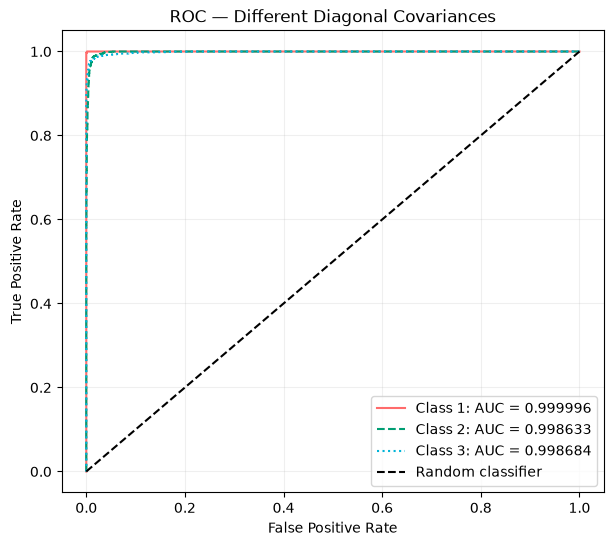

In [197]:
#roc curves
shifted = test_scores - test_scores.max(axis=1, keepdims=True)
probabilities = np.exp(shifted)
probabilities /= probabilities.sum(axis=1, keepdims=True)

styles = ["-", "--", ":"]
plt.figure(figsize=(7, 6))

for k in range(3):
    positive = (actual == k)
    scores_k = probabilities[:, k]

    order = np.argsort(-scores_k)
    sorted_scores = scores_k[order]
    sorted_positive = positive[order]

    ends = np.r_[np.where(np.diff(sorted_scores) != 0)[0],
                 len(sorted_scores) - 1]

    tp = np.cumsum(sorted_positive)[ends]
    fp = np.cumsum(~sorted_positive)[ends]

    tpr = np.r_[0, tp / positive.sum()]
    fpr = np.r_[0, fp / (~positive).sum()]

    auc = np.sum(np.diff(fpr) * (tpr[:-1] + tpr[1:]) / 2)

    plt.plot(
        fpr, tpr, color=colors[k], linestyle=styles[k],
        label=f"Class {k+1}: AUC = {auc:.6f}"
    )

plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Different Diagonal Covariances")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


In [198]:
#full covariance with shared covariance
full_covariance = np.array([[1.0, 0.5],
                            [0.5, 2.0]])

class1 = rng.multivariate_normal([-5, -2], full_covariance, size=10000)
class2 = rng.multivariate_normal([0, 5], full_covariance, size=10000)
class3 = rng.multivariate_normal([5, 0], full_covariance, size=10000)

for data in (class1, class2, class3): rng.shuffle(data)
(train1, test1), (train2, test2), (train3, test3) = [
    (data[:8000], data[8000:]) for data in (class1, class2, class3)
]

training = (train1, train2, train3)
means = np.array([data.mean(axis=0) for data in training])

# Pool scatter around each class's own estimated mean.
scatter = np.zeros((2, 2))
for k, data in enumerate(training):
    centered = data - means[k]
    scatter += centered.T @ centered

shared_full_covariance = scatter / sum(len(data) for data in training)
A = np.linalg.inv(shared_full_covariance)

print("Estimated means:\n", means)
print("Estimated shared full covariance:\n", shared_full_covariance)

Estimated means:
 [[-4.99410254e+00 -1.98229171e+00]
 [ 5.63886721e-03  4.99620905e+00]
 [ 4.99769428e+00 -4.28534402e-03]]
Estimated shared full covariance:
 [[1.01205074 0.50069202]
 [0.50069202 1.98629452]]


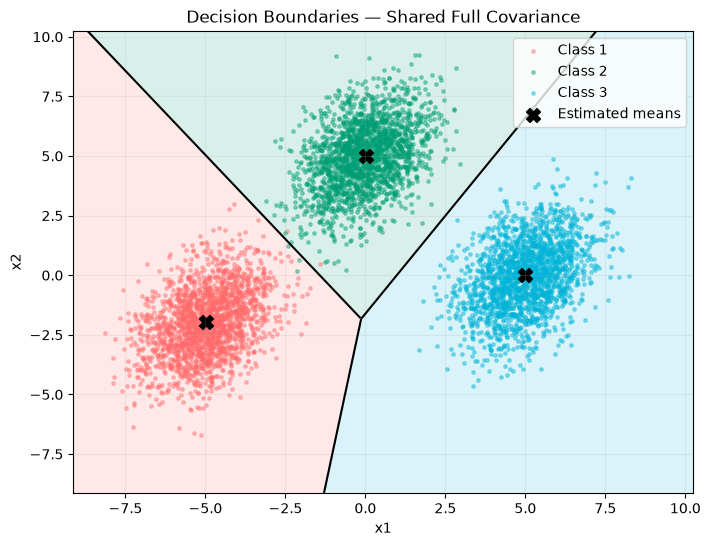

In [200]:
test_data = np.vstack((test1, test2, test3))

lower = test_data.min() - 1
upper = test_data.max() + 1

x1, x2 = np.meshgrid(
    np.linspace(lower, upper, 400),
    np.linspace(lower, upper, 400)
)
points = np.column_stack((x1.ravel(), x2.ravel()))

scores = points @ A @ means.T - 0.5 * np.sum((means @ A) * means, axis=1)
regions = np.argmax(scores, axis=1).reshape(x1.shape)

plt.figure(figsize=(8, 6))
plt.contourf(
    x1, x2, regions,
    levels=[-0.5, 0.5, 1.5, 2.5],
    colors=colors, alpha=0.15
)

for i, j in [(0, 1), (0, 2), (1, 2)]:
    third = 3 - i - j
    difference = (scores[:, i] - scores[:, j]).reshape(x1.shape)
    active = (
        np.maximum(scores[:, i], scores[:, j]) >= scores[:, third]
    ).reshape(x1.shape)

    boundary = np.ma.masked_where(~active, difference)
    values = boundary.compressed()

    if values.size and values.min() < 0 < values.max():
        plt.contour(
            x1, x2, boundary, levels=[0],
            colors="black", linewidths=1.5
        )

for k, data in enumerate((test1, test2, test3)):
    plt.scatter(
        data[:, 0], data[:, 1],
        s=6, alpha=0.4, color=colors[k], label=f"Class {k+1}"
    )

plt.scatter(
    means[:, 0], means[:, 1],
    marker="X", s=100, color="black", label="Estimated means"
)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Decision Boundaries — Shared Full Covariance")
plt.legend()
plt.grid(alpha=0.2)
plt.xlim(lower, upper)
plt.ylim(lower, upper)
plt.gca().set_aspect("auto")
plt.show()

In [201]:
actual = np.concatenate([
    np.full(len(data), k)
    for k, data in enumerate((test1, test2, test3))
])

test_scores = test_data @ A @ means.T - 0.5 * np.sum((means @ A) * means, axis=1)
predicted = np.argmax(test_scores, axis=1)

confusion_matrix = np.zeros((3, 3), dtype=int)
np.add.at(confusion_matrix, (actual, predicted), 1)

print("Confusion matrix (rows: actual, columns: predicted):")
print(confusion_matrix)
print(f"Test accuracy: {np.trace(confusion_matrix) / confusion_matrix.sum() * 100:.2f}%")

Confusion matrix (rows: actual, columns: predicted):
[[1998    2    0]
 [   3 1997    0]
 [   0    0 2000]]
Test accuracy: 99.92%


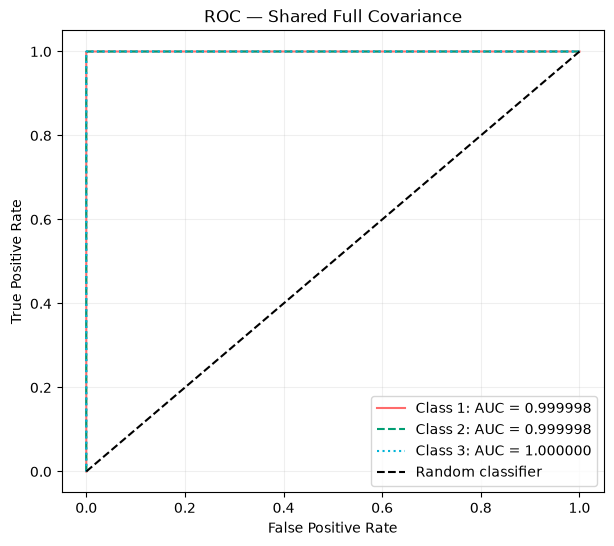

In [202]:
shifted = test_scores - test_scores.max(axis=1, keepdims=True)
probabilities = np.exp(shifted)
probabilities /= probabilities.sum(axis=1, keepdims=True)

styles = ["-", "--", ":"]
plt.figure(figsize=(7, 6))

for k in range(3):
    positive = (actual == k)
    scores_k = probabilities[:, k]

    order = np.argsort(-scores_k)
    sorted_scores = scores_k[order]
    sorted_positive = positive[order]

    ends = np.r_[np.where(np.diff(sorted_scores) != 0)[0],
                 len(sorted_scores) - 1]

    tp = np.cumsum(sorted_positive)[ends]
    fp = np.cumsum(~sorted_positive)[ends]

    tpr = np.r_[0, tp / positive.sum()]
    fpr = np.r_[0, fp / (~positive).sum()]

    auc = np.sum(np.diff(fpr) * (tpr[:-1] + tpr[1:]) / 2)

    plt.plot(
        fpr, tpr, color=colors[k], linestyle=styles[k],
        label=f"Class {k+1}: AUC = {auc:.6f}"
    )

plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Shared Full Covariance")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [203]:
#full covariance with different covariance
full_covariances = np.array([
    [[1.0,  0.6], [ 0.6, 2.0]],
    [[2.0, -0.5], [-0.5, 5.0]],
    [[4.0,  0.8], [ 0.8, 3.0]]
])

class1 = rng.multivariate_normal([-5, -2], full_covariances[0], size=10000)
class2 = rng.multivariate_normal([0, 5], full_covariances[1], size=10000)
class3 = rng.multivariate_normal([5, 0], full_covariances[2], size=10000)

for data in (class1, class2, class3): rng.shuffle(data)
(train1, test1), (train2, test2), (train3, test3) = [
    (data[:8000], data[8000:]) for data in (class1, class2, class3)
]

training = (train1, train2, train3)
means = np.array([data.mean(axis=0) for data in training])
estimated_full_covariances = np.zeros((3, 2, 2))

for k, data in enumerate(training):
    centered = data - means[k]
    estimated_full_covariances[k] = centered.T @ centered / len(data)

    print(f"Class {k+1}: Mean = {means[k]}")
    print("Estimated full covariance:\n", estimated_full_covariances[k])

inverses = np.linalg.inv(estimated_full_covariances)
log_determinants = np.linalg.slogdet(estimated_full_covariances)[1]

Class 1: Mean = [-5.00726949 -1.99353892]
Estimated full covariance:
 [[0.99542619 0.59566405]
 [0.59566405 1.98307546]]
Class 2: Mean = [-0.03512972  4.99738011]
Estimated full covariance:
 [[ 2.02664114 -0.54024362]
 [-0.54024362  5.16623422]]
Class 3: Mean = [4.96904363 0.0135438 ]
Estimated full covariance:
 [[3.94661307 0.73796008]
 [0.73796008 3.00711208]]


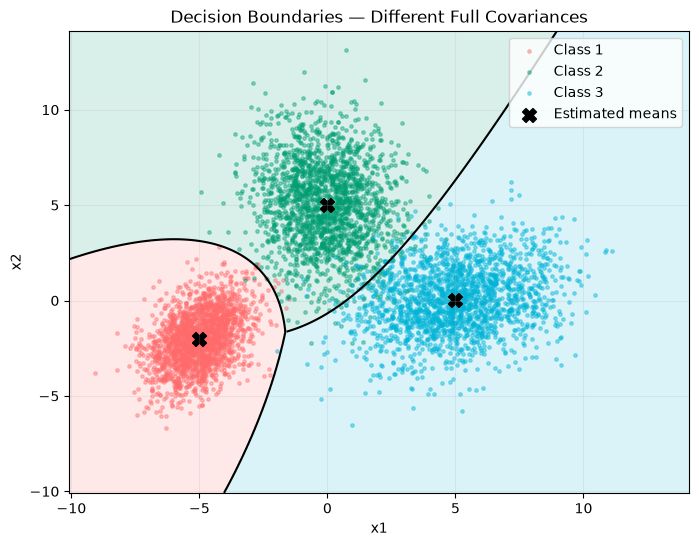

In [204]:
test_data = np.vstack((test1, test2, test3))

lower = test_data.min() - 1
upper = test_data.max() + 1

x1, x2 = np.meshgrid(
    np.linspace(lower, upper, 400),
    np.linspace(lower, upper, 400)
)
points = np.column_stack((x1.ravel(), x2.ravel()))

scores = np.zeros((len(points), 3))

for k in range(3):
    difference = points - means[k]
    scores[:, k] = (
        -0.5 * np.sum((difference @ inverses[k]) * difference, axis=1)
        -0.5 * log_determinants[k]
    )

regions = np.argmax(scores, axis=1).reshape(x1.shape)

plt.figure(figsize=(8, 6))
plt.contourf(
    x1, x2, regions,
    levels=[-0.5, 0.5, 1.5, 2.5],
    colors=colors, alpha=0.15
)

for i, j in [(0, 1), (0, 2), (1, 2)]:
    third = 3 - i - j
    difference = (scores[:, i] - scores[:, j]).reshape(x1.shape)
    active = (
        np.maximum(scores[:, i], scores[:, j]) >= scores[:, third]
    ).reshape(x1.shape)

    boundary = np.ma.masked_where(~active, difference)
    values = boundary.compressed()

    if values.size and values.min() < 0 < values.max():
        plt.contour(
            x1, x2, boundary, levels=[0],
            colors="black", linewidths=1.5
        )

for k, data in enumerate((test1, test2, test3)):
    plt.scatter(
        data[:, 0], data[:, 1],
        s=6, alpha=0.4, color=colors[k], label=f"Class {k+1}"
    )

plt.scatter(
    means[:, 0], means[:, 1],
    marker="X", s=100, color="black", label="Estimated means"
)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Decision Boundaries — Different Full Covariances")
plt.legend()
plt.grid(alpha=0.2)
plt.xlim(lower, upper)
plt.ylim(lower, upper)
plt.gca().set_aspect("auto")
plt.show()

In [205]:
actual = np.concatenate([
    np.full(len(data), k)
    for k, data in enumerate((test1, test2, test3))
])

test_scores = np.zeros((len(test_data), 3))

for k in range(3):
    difference = test_data - means[k]
    test_scores[:, k] = (
        -0.5 * np.sum((difference @ inverses[k]) * difference, axis=1)
        -0.5 * log_determinants[k]
    )

predicted = np.argmax(test_scores, axis=1)

confusion_matrix = np.zeros((3, 3), dtype=int)
np.add.at(confusion_matrix, (actual, predicted), 1)

print("Confusion matrix (rows: actual, columns: predicted):")
print(confusion_matrix)
print(f"Test accuracy: {np.trace(confusion_matrix) / confusion_matrix.sum() * 100:.2f}%")

Confusion matrix (rows: actual, columns: predicted):
[[1989   11    0]
 [   3 1939   58]
 [   1   44 1955]]
Test accuracy: 98.05%


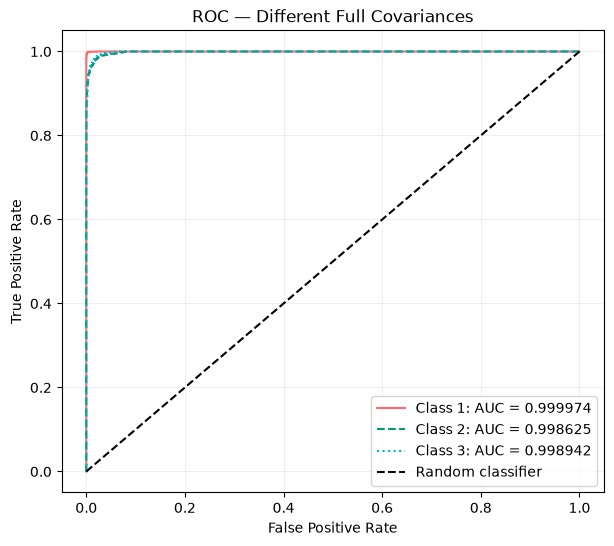

In [206]:
shifted = test_scores - test_scores.max(axis=1, keepdims=True)
probabilities = np.exp(shifted)
probabilities /= probabilities.sum(axis=1, keepdims=True)

styles = ["-", "--", ":"]
plt.figure(figsize=(7, 6))

for k in range(3):
    positive = (actual == k)
    scores_k = probabilities[:, k]

    order = np.argsort(-scores_k)
    sorted_scores = scores_k[order]
    sorted_positive = positive[order]

    ends = np.r_[np.where(np.diff(sorted_scores) != 0)[0],
                 len(sorted_scores) - 1]

    tp = np.cumsum(sorted_positive)[ends]
    fp = np.cumsum(~sorted_positive)[ends]

    tpr = np.r_[0, tp / positive.sum()]
    fpr = np.r_[0, fp / (~positive).sum()]

    auc = np.sum(np.diff(fpr) * (tpr[:-1] + tpr[1:]) / 2)

    plt.plot(
        fpr, tpr, color=colors[k], linestyle=styles[k],
        label=f"Class {k+1}: AUC = {auc:.6f}"
    )

plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Different Full Covariances")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [207]:
#dataset
import numpy as np
import matplotlib.pyplot as plt

train_data = np.loadtxt(r"C:\Users\hp\ml\lab5\trian.txt", delimiter=",")
dev_data = np.loadtxt(r"C:\Users\hp\ml\lab5\dev.txt", delimiter=",")

X_train = train_data[:, :2]
y_train = train_data[:, 2].astype(int)

test_data = dev_data[:, :2]
test_labels = dev_data[:, 2].astype(int)

classes = np.unique(y_train)
n_classes = len(classes)

means = np.zeros((n_classes, 2))
covariances = np.zeros((n_classes, 2, 2))
priors = np.zeros(n_classes)

for k, label in enumerate(classes):
    data = X_train[y_train == label]
    means[k] = data.mean(axis=0)

    centered = data - means[k]
    covariances[k] = centered.T @ centered / len(data)
    priors[k] = len(data) / len(X_train)

    print(f"\nClass {label}:")
    print(f"Estimated mean: [{means[k, 0]:.4f}, {means[k, 1]:.4f}]")
    print("Estimated covariance:\n", covariances[k])

inverses = np.linalg.inv(covariances)
signs, log_determinants = np.linalg.slogdet(covariances)

if np.any(signs <= 0):
    raise ValueError("Covariance matrices must be positive definite.")


Class 1:
Estimated mean: [577.3632, 1439.7703]
Estimated covariance:
 [[23301.72076415  2675.42155356]
 [ 2675.42155356 54428.45370819]]

Class 2:
Estimated mean: [366.3392, 1920.5537]
Estimated covariance:
 [[ 13097.71116793 -10341.96894048]
 [-10341.96894048  53935.21768956]]

Class 3:
Estimated mean: [416.4436, 1255.7254]
Estimated covariance:
 [[ 24863.14561267  36792.25273729]
 [ 36792.25273729 196708.38323113]]


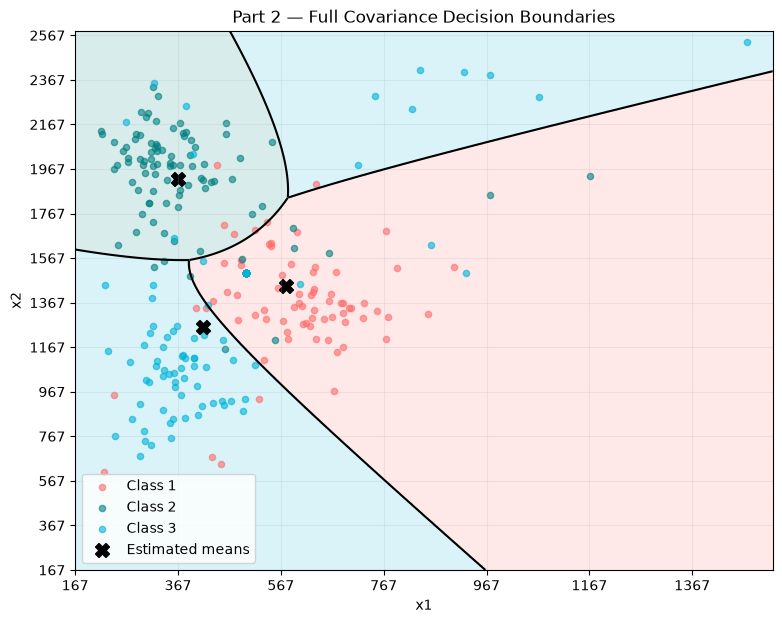

In [208]:
colors = ["#FF6B6B", "#008080", "#00B4D8"]

lower = test_data.min() - 50
x_upper = test_data[:, 0].max() + 50
y_upper = test_data[:, 1].max() + 50

x1, x2 = np.meshgrid(
    np.linspace(lower, x_upper, 400),
    np.linspace(lower, y_upper, 400)
)
points = np.column_stack((x1.ravel(), x2.ravel()))

scores = np.zeros((len(points), n_classes))

for k in range(n_classes):
    difference = points - means[k]
    scores[:, k] = (
        -0.5 * np.sum((difference @ inverses[k]) * difference, axis=1)
        -0.5 * log_determinants[k]
        + np.log(priors[k])
    )

regions = np.argmax(scores, axis=1).reshape(x1.shape)

plt.figure(figsize=(9, 7))
plt.contourf(
    x1, x2, regions,
    levels=[-0.5, 0.5, 1.5, 2.5],
    colors=colors, alpha=0.15
)

for i, j in [(0, 1), (0, 2), (1, 2)]:
    third = 3 - i - j
    difference = (scores[:, i] - scores[:, j]).reshape(x1.shape)
    active = (
        np.maximum(scores[:, i], scores[:, j]) >= scores[:, third]
    ).reshape(x1.shape)

    boundary = np.ma.masked_where(~active, difference)
    values = boundary.compressed()

    if values.size and values.min() < 0 < values.max():
        plt.contour(
            x1, x2, boundary, levels=[0],
            colors="black", linewidths=1.5
        )

for k, label in enumerate(classes):
    data = test_data[test_labels == label]
    plt.scatter(
        data[:, 0], data[:, 1],
        s=20, alpha=0.6, color=colors[k],
        label=f"Class {label}"
    )

plt.scatter(
    means[:, 0], means[:, 1],
    marker="X", s=100, color="black",
    label="Estimated means"
)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Part 2 — Full Covariance Decision Boundaries")
plt.legend()
plt.grid(alpha=0.2)
plt.xlim(lower, x_upper)
plt.ylim(lower, y_upper)
plt.xticks(np.arange(lower, x_upper + 1, 200))
plt.yticks(np.arange(lower, y_upper + 1, 200))
plt.show()

In [209]:
# Convert file labels 1, 2, 3 into array indices 0, 1, 2.
actual = np.zeros(len(test_labels), dtype=int)
for k, label in enumerate(classes):
    actual[test_labels == label] = k

test_scores = np.zeros((len(test_data), n_classes))

for k in range(n_classes):
    difference = test_data - means[k]
    test_scores[:, k] = (
        -0.5 * np.sum((difference @ inverses[k]) * difference, axis=1)
        -0.5 * log_determinants[k]
        + np.log(priors[k])
    )

predicted = np.argmax(test_scores, axis=1)

confusion_matrix = np.zeros((n_classes, n_classes), dtype=int)
np.add.at(confusion_matrix, (actual, predicted), 1)

print("Class order:", classes)
print("Confusion matrix (rows: actual, columns: predicted):")
print(confusion_matrix)
print(f"Test accuracy: {np.trace(confusion_matrix) / confusion_matrix.sum() * 100:.2f}%")

Class order: [1 2 3]
Confusion matrix (rows: actual, columns: predicted):
[[87  5  8]
 [17 79  4]
 [29  5 66]]
Test accuracy: 77.33%


Class 1: AUC = 0.878150
Class 2: AUC = 0.922750
Class 3: AUC = 0.876400


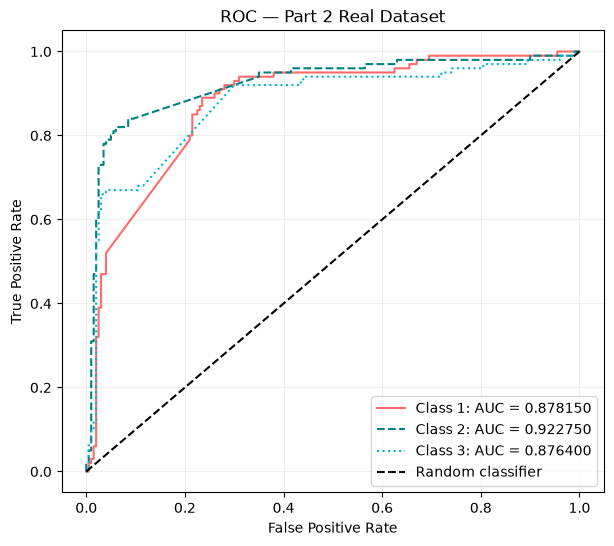

In [210]:
shifted = test_scores - test_scores.max(axis=1, keepdims=True)
probabilities = np.exp(shifted)
probabilities /= probabilities.sum(axis=1, keepdims=True)

styles = ["-", "--", ":"]
plt.figure(figsize=(7, 6))

for k, label in enumerate(classes):
    positive = (actual == k)
    scores_k = probabilities[:, k]

    order = np.argsort(-scores_k)
    sorted_scores = scores_k[order]
    sorted_positive = positive[order]

    ends = np.r_[np.where(np.diff(sorted_scores) != 0)[0],
                 len(sorted_scores) - 1]

    tp = np.cumsum(sorted_positive)[ends]
    fp = np.cumsum(~sorted_positive)[ends]

    tpr = np.r_[0, tp / positive.sum()]
    fpr = np.r_[0, fp / (~positive).sum()]

    auc = np.sum(np.diff(fpr) * (tpr[:-1] + tpr[1:]) / 2)

    print(f"Class {label}: AUC = {auc:.6f}")
    plt.plot(
        fpr, tpr, color=colors[k], linestyle=styles[k],
        label=f"Class {label}: AUC = {auc:.6f}"
    )

plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Part 2 Real Dataset")
plt.legend()
plt.grid(alpha=0.2)
plt.show()